In [1]:
pip install boto3 pandas s3fs

Defaulting to user installation because normal site-packages is not writeable
  Using cached boto3-1.42.73-py3-none-any.whl.metadata (6.7 kB)
  Using cached botocore-1.42.73-py3-none-any.whl.metadata (5.9 kB)
  Using cached s3transfer-0.16.0-py3-none-any.whl.metadata (1.7 kB)
INFO: pip is looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
  Using cached aiobotocore-2.26.0-py3-none-any.whl.metadata (25 kB)
  Using cached aiobotocore-2.25.2-py3-none-any.whl.metadata (25 kB)
  Using cached aiobotocore-2.25.1-py3-none-any.whl.metadata (25 kB)
  Using cached aiobotocore-2.24.3-py3-none-any.whl.metadata (25 kB)
  Using cached aiobotocore-2.24.2-py3-none-any.whl.metadata (25 kB)
  Using cached aiobotocore-2.24.1-py3-none-any.whl.metadata (25 kB)
  Using cached aiobotocore-2.24.0-py3-none-any.whl.metadata (25 kB)
INFO: pip is still looking at multiple versions of aiobotocore to determine which version is compat

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.25.0 requires botocore<1.40.50,>=1.40.46, but you have botocore 1.42.73 which is incompatible.


In [1]:
import boto3
import pandas as pd
from io import BytesIO
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

s3 = boto3.client(
    "s3",
    aws_access_key_id="YOUR KEY",
    aws_secret_access_key="USE YOUR KEY",
    region_name="eu-north-1"
)

obj = s3.get_object(
    Bucket="ecommerce-analytics-s3-storage1",
    Key="global_ecommerce_dataset.csv"
)

df = pd.read_csv(BytesIO(obj["Body"].read()))

df.head(10)

,Order ID,Customer ID,Customer Name,Region,Country,City,Category,Sub Category,Product Name,Sales,Quantity,Profit,Order Date,Ship Date,Segment,Discount,Shipping Cost,Payment Method,Order Priority
0,ORD-135466,CUST-23208,Susan Kowalski,Asia Pacific,India,Chennai,Furniture,Storage,IKEA ALEX Drawer Unit,284.98,2,82.56,2020-08-02,2020-08-09,Consumer,0.05,13.16,PayPal,High
1,ORD-170555,CUST-10565,David Okafor,North America,United States,Phoenix,Furniture,Chairs,HON Ignition 2.0 Chair,$399.99,1,-125.63,2023-10-24,2023-11-02,Corporate,0.00,19.87,Bank Transfer,Low
2,ORD-145242,CUST-58925,Fatima Johnson,Middle East,Saudi Arabia,Medina,Office Supplies,Appliances,Swingline Stapler,19.99,1,5.88,2018-03-05,2018-03-16,Consumer,0.00,33.74,Bank Transfer,High
3,ORD-100800,CUST-97580,Charles Thompson,Asia Pacific,India,Delhi,Technology,Machines,ASUS ZenBook 14,1614.98,2,546.77,2022-09-12,2022-09-25,Corporate,0.05,42.12,PayPal,High
4,ORD-101350,CUST-64935,Wei Moore,Asia Pacific,India,Chennai,Technology,Machines,Dell XPS 15 Laptop,2000.0,3,613.23,2019-05-08,2019-05-11,Consumer,0.00,45.17,Credit Card,Low
5,ORD-151599,CUST-42613,Nadia Smith,Europe,Germany,Hamburg,Furniture,Tables,FlexiSpot E7 Standing Desk,1799.96,4,180.98,2025-04-02,2025-04-14,Corporate,0.10,47.68,Crypto,Medium
6,ORD-138976,CUST-58751,Lisa Rossi,North America,Mexico,Puebla,Technology,Copiers,Xerox B210 Printer,873.96,4,193.18,2018-04-03,2018-04-14,Corporate,0.05,43.72,Bank Transfer,Medium
7,ORD-125576,CUST-48748,Ivan Novak,Middle East,Israel,Jerusalem,Technology,Accessories,Sony WH-1000XM5 Headphones,NaN,2,-77.29,2021-09-21,NaN,Home Office,0.00,49.62,Debit Card,High
8,ORD-120382,CUST-24681,Thomas Harris,Europe,Spain,Madrid,Technology,Copiers,Xerox B210 Printer,367.98,2,30.54,2024-01-10,NaN,Consumer,0.20,33.82,PayPal,High
9,ORD-101618,CUST-47938,Chen Chen,Asia Pacific,South Korea,Seoul,Office Supplies,Binders,Samsill Earth Choice Binder,21.58,2,5.53,2024-02-25,2024-03-07,Home Office,0.10,31.94,Credit Card,High


In [2]:
df['Quantity'] = df['Quantity'].str.replace(' units','').astype(int)

df['Sales'] = df['Sales'].replace('[\$,]', '', regex=True)
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

In [3]:
df.isnull().sum()

Order ID             0
Customer ID          0
Customer Name        0
Region              99
Country              0
City              1642
Category             0
Sub Category         0
Product Name         0
Sales             2176
Quantity             0
Profit            1962
Order Date           0
Ship Date         2167
Segment              0
Discount             0
Shipping Cost        0
Payment Method       0
Order Priority       0
dtype: int64

In [4]:
df['Region'].fillna(df['Region'].mode()[0], inplace=True)
df['City'].fillna("unkown", inplace=True)
df['Sales'].fillna(df['Sales'].median(), inplace=True)
df['Profit'].fillna(df['Profit'].median(), inplace=True)
df['Ship Date'].fillna(df['Order Date'], inplace=True)
df.isnull().sum()

C:\Users\hp\AppData\Local\Temp\ipykernel_16640\3515888295.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Region'].fillna(df['Region'].mode()[0], inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_16640\3515888295.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

Order ID          0
Customer ID       0
Customer Name     0
Region            0
Country           0
City              0
Category          0
Sub Category      0
Product Name      0
Sales             0
Quantity          0
Profit            0
Order Date        0
Ship Date         0
Segment           0
Discount          0
Shipping Cost     0
Payment Method    0
Order Priority    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(1620)

In [6]:
df['Order ID'].duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
109615    False
109616    False
109617    False
109618    False
109619    False
Name: Order ID, Length: 109620, dtype: bool

In [7]:
df[df.duplicated(subset=['Order ID','Ship Date'], keep=False)].sort_values('Order ID')

,Order ID,Customer ID,Customer Name,Region,Country,City,Category,Sub Category,Product Name,Sales,Quantity,Profit,Order Date,Ship Date,Segment,Discount,Shipping Cost,Payment Method,Order Priority
97665,ORD-100281,CUST-95477,Michael Fernandez,North America,Canada,Toronto,Technology,Accessories,Sony WH-1000XM5 Headphones,997.47,3,76.28,2020-03-26,2020-04-05,Consumer,0.05,17.98,Bank Transfer,Medium
56633,ORD-100281,CUST-95477,Michael Fernandez,North America,Canada,Toronto,Technology,Accessories,Sony WH-1000XM5 Headphones,997.47,3,76.28,2020-03-26,2020-04-05,Consumer,0.05,17.98,Bank Transfer,Medium
973,ORD-100343,CUST-51467,Omar Anderson,Asia Pacific,China,Shenzhen,Furniture,Tables,IKEA BEKANT Desk,419.99,2,97.05,2022-08-14,2022-08-27,Consumer,0.30,24.42,Debit Card,Low
5276,ORD-100343,CUST-51467,Omar Anderson,Asia Pacific,China,Shenzhen,Furniture,Tables,IKEA BEKANT Desk,419.99,2,97.05,2022-08-14,2022-08-27,Consumer,0.30,24.42,Debit Card,Low
50684,ORD-100345,CUST-36772,Omar Andersen,North America,Mexico,Mexico City,Office Supplies,Appliances,Fellowes Shredder,62.99,1,-7.82,2024-12-12,2024-12-20,Corporate,0.30,10.76,Credit Card,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105863,ORD-207685,CUST-54637,Arjun Martin,Africa,Egypt,Giza,Technology,Machines,HP Spectre x360,2000.00,2,561.86,2022-10-11,2022-10-17,Consumer,0.05,18.28,Bank Transfer,High
103620,ORD-207911,CUST-78489,Sarah Wang,Africa,Egypt,Giza,Furniture,Tables,Sauder Beginnings Desk,129.99,1,37.33,2022-02-01,2022-02-09,Consumer,0.00,45.23,Debit Card,High
86862,ORD-207911,CUST-78489,Sarah Wang,Africa,Egypt,Giza,Furniture,Tables,Sauder Beginnings Desk,129.99,1,37.33,2022-02-01,2022-02-09,Consumer,0.00,45.23,Debit Card,High
11680,ORD-207917,CUST-35804,Mei Miller,Asia Pacific,Japan,Yokohama,Technology,Phones,Motorola Edge 40,559.99,2,-174.07,2021-09-13,2021-09-16,Consumer,0.30,48.74,PayPal,Medium


In [8]:
df = df.drop_duplicates(subset=['Order ID','Ship Date'])
df.duplicated().sum()

np.int64(0)

In [9]:
df.groupby('Region')['Sales'].sum()

Region
 Africa              266399.10
 Asia Pacific        707585.26
 Europe             1812006.96
 Middle East         540181.67
 North America      1875020.25
 South America       340643.99
??                   102174.64
Africa              8354786.79
Asia Pacific       26193743.48
Atlantis              59883.83
Europe             32657383.17
INVALID              236780.28
Mars                  47727.55
Middle East        13028728.54
North America      36569649.24
South America      10249569.23
Unknown               59795.58
Name: Sales, dtype: float64

In [10]:
df['Region'].unique()

array(['Asia Pacific', 'North America', ' Middle East ', ' Europe ',
       'Middle East', 'Europe', 'Africa', 'South America',
       ' North America ', ' Asia Pacific ', ' Africa ', ' South America ',
       'Unknown', 'Mars', 'INVALID', 'Atlantis', '??'], dtype=object)

In [11]:
df['Region'] = df['Region'].replace(
    ['??', 'Unknown', 'INVALID', 'Mars', 'Atlantis'],
    np.nan
)
df['Region'].unique()

array(['Asia Pacific', 'North America', ' Middle East ', ' Europe ',
       'Middle East', 'Europe', 'Africa', 'South America',
       ' North America ', ' Asia Pacific ', ' Africa ', ' South America ',
       nan], dtype=object)

In [12]:
df['Country'].unique()

array(['India', 'United States', 'Saudi Arabia', 'Germany', 'Mexico',
       'Israel', 'Spain', 'South Korea', 'Kenya', 'Japan', 'Brazil',
       'Colombia', 'Canada', 'Egypt', 'Nigeria', 'South Africa',
       'United Kingdom', 'France', 'Chile', 'Australia', 'China', 'Qatar',
       'Argentina', 'Italy', 'UAE'], dtype=object)

In [13]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

Product Name
Dell XPS 15 Laptop             6325862.96
MacBook Pro M3                 5228354.81
HP Spectre x360                5102672.63
Herman Miller Aeron Chair      4493278.19
Lenovo ThinkPad X1             4447679.50
Steelcase Leap V2              4441486.17
Avery Heavy Duty Binder 3in    4297703.37
Samsung Galaxy S23             3641781.81
IKEA BEKANT Desk               3613633.66
ASUS ZenBook 14                3529854.41
Name: Sales, dtype: float64

C:\Users\hp\AppData\Local\Temp\ipykernel_16640\1072112833.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


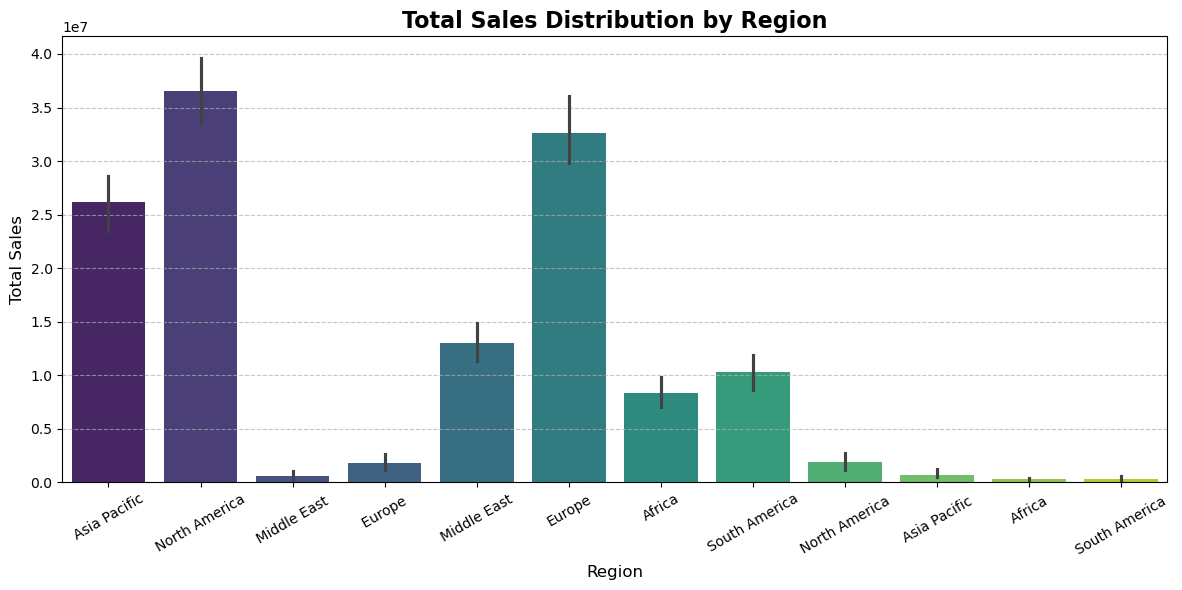

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='Region',
    y='Sales',
    estimator=sum,
    palette='viridis'
)

plt.title("Total Sales Distribution by Region", fontsize=16, fontweight='bold')
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

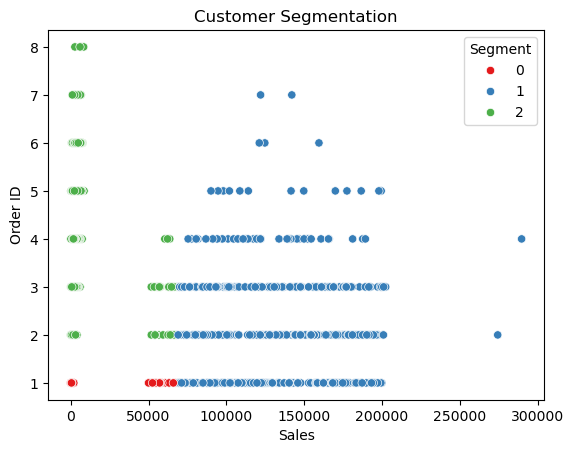

In [15]:
customer_data = df.groupby('Customer ID').agg({
    'Sales':'sum',
    'Order ID':'nunique'
}).reset_index()

scaler = StandardScaler()
X = scaler.fit_transform(customer_data[['Sales','Order ID']])

kmeans = KMeans(n_clusters=3, random_state=42)
customer_data['Segment'] = kmeans.fit_predict(X)

sns.scatterplot(
    data=customer_data,
    x='Sales',
    y='Order ID',
    hue='Segment',
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.show()

In [ ]:
df.to_csv('cleaned_ecommerce_data.csv', index=False)